# AGN vs TDE Classification: ASTROMER Embedding Pipeline

Transformer-based pipeline in `fluctuant`:
1. Synthetic AGN and TDE light curves (DRW + power-law decay)
2. Pretrained [ASTROMER](https://github.com/astromer-science/main-code) encoder → 256-dim per timestep (MACHO weights)
3. 7-statistic pooling → 1792-dim feature vector per light curve
4. Random Forest classifier

**Requirements:** TensorFlow 2.13 and the ASTROMER MACHO pretrained weights (in `weights/macho/` relative to the working directory).

In [1]:
import matplotlib.pyplot as plt

from fluctuant.pipelines import AstromerPipeline
from fluctuant.utils import (
    plot_evaluation_curves,
    create_confusion_matrix_plot,
    analyze_feature_importance,
)

## Step 1: Generate synthetic light curves

AGN are modeled as a Damped Random Walk (DRW) with optional fast-rise/exponential-decay flares superimposed (50% of objects). TDEs use a cosine rise followed by a blended power-law/exponential decay. Both use realistic irregular cadence drawn from an exponential distribution with occasional 20–60 day gaps.

In [2]:
pipeline = AstromerPipeline(seed=42, pretrained_weights='macho')

lcs, labels = pipeline.generate_dataset(n_agn=500, n_tde=500)
print(f"Light curves: {len(lcs)}  |  AGN: {(labels == 0).sum()}  |  TDE: {(labels == 1).sum()}")
print(f"Example light curve shape: {lcs[0].shape}  (columns: time, mag, err)")

[INFO] Weights already downloaded
Generating 500 AGN and 500 TDE light curves...
Total: 1000 light curves
Light curves: 1000  |  AGN: 500  |  TDE: 500
Example light curve shape: (204, 3)  (columns: time, mag, err)


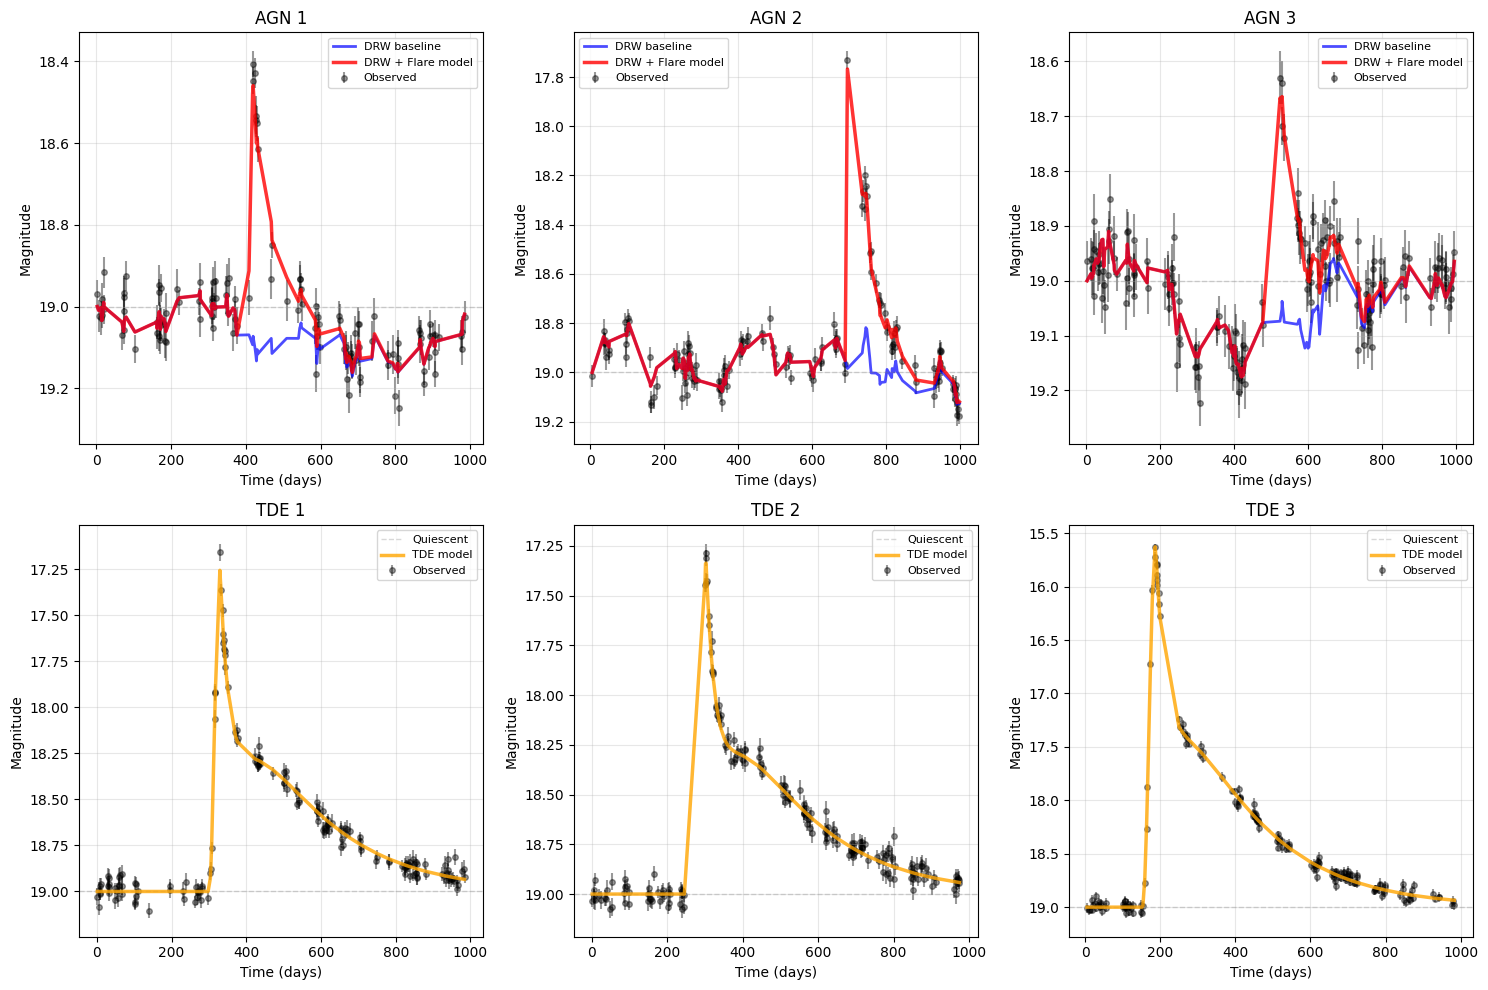

In [3]:
# Plot example AGN and TDE light curves with their generating model overlaid
fig = pipeline.plot_example_lightcurves(n_examples=3)
plt.show()

## Step 2: Preprocess

Subtract the per-light-curve mean from both time and magnitude columns. ASTROMER's internal data loader does the same normalization, so this ensures our data is already centered before it enters the model.

In [4]:
pipeline.preprocess()

import numpy as np
lc = pipeline.light_curves[0]
print(f"Time mean after preprocessing:  {lc[:, 0].mean():.2e}")
print(f"Mag  mean after preprocessing:  {lc[:, 1].mean():.2e}")

Time mean after preprocessing:  1.78e-14
Mag  mean after preprocessing:  8.01e-16


## Step 3: Generate ASTROMER embeddings

Each light curve is passed through the pretrained transformer encoder (2-layer, `d_model=256`, pretrained on MACHO variable stars). The encoder outputs one 256-dimensional vector per observation timestep.

We then collapse the temporal dimension with 7 statistics: mean, std, 25th percentile, 75th percentile, temporal gradient mean, approximate skewness, and early-minus-late mean; giving a **1792-dimensional** feature vector per light curve (7 × 256).

In [5]:
embeddings = pipeline.generate_embeddings()

n_samples, n_features = embeddings.shape
print(f"Embedding matrix: {n_samples} samples × {n_features} features")
print(f"  = {n_samples} light curves × (7 statistics × 256 ASTROMER dims)")

Generating embeddings...
[INFO] Loading numpy arrays
[INFO] no masking
Embeddings shape: (1000, 1792)
Embedding matrix: 1000 samples × 1792 features
  = 1000 light curves × (7 statistics × 256 ASTROMER dims)


## Step 4: Train the classifier

Features are first standardized (zero mean, unit variance per dimension), then a Random Forest is trained on a 70/30 stratified split. 5-fold cross-validation on the training set gives an unbiased AUC estimate.

In [6]:
clf, (X_train, X_test, y_train, y_test, y_proba) = pipeline.train_classifier(
    test_size=0.3,
    tune_hyperparams=False,  # set True for grid-search (slower)
)


Training classifier...
CV ROC-AUC: 0.508 ± 0.044

              precision    recall  f1-score   support

         AGN      0.543     0.507     0.524       150
         TDE      0.537     0.573     0.555       150

    accuracy                          0.540       300
   macro avg      0.540     0.540     0.539       300
weighted avg      0.540     0.540     0.539       300

Confusion Matrix:
           Predicted
           AGN    TDE
Actual AGN   76     74
       TDE   64     86

ROC AUC: 0.543
Avg Precision: 0.537


## Step 5 — Evaluate

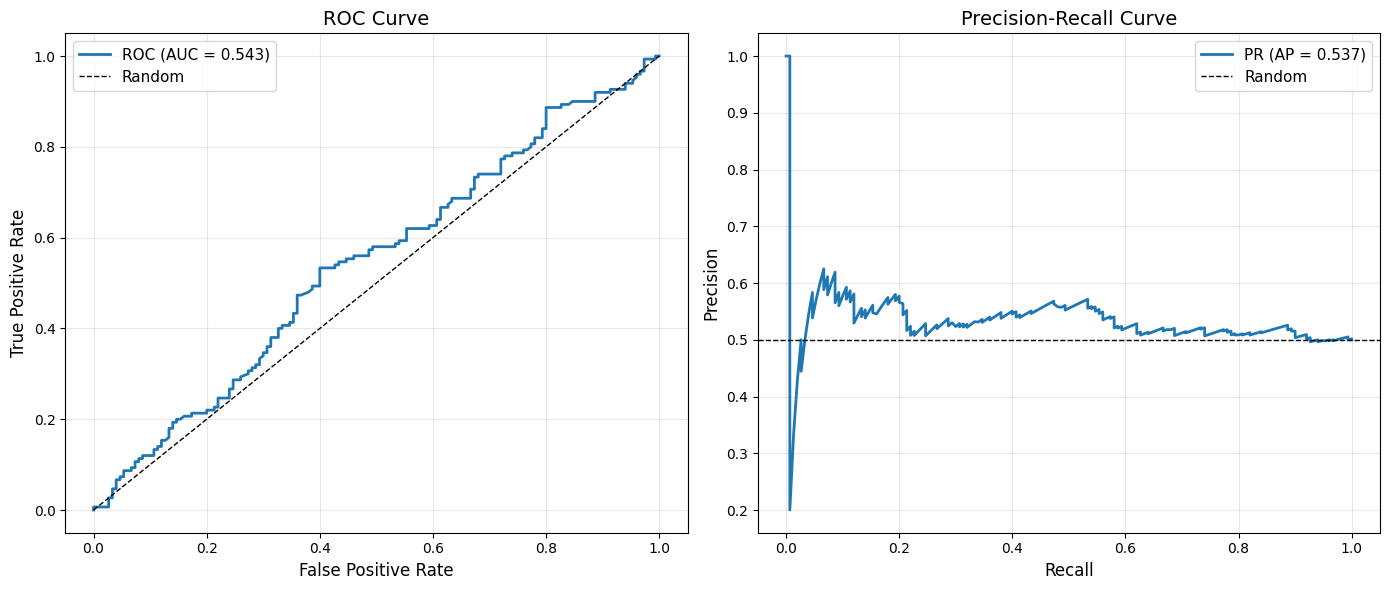

In [7]:
fig = plot_evaluation_curves(y_test, y_proba)
plt.show()

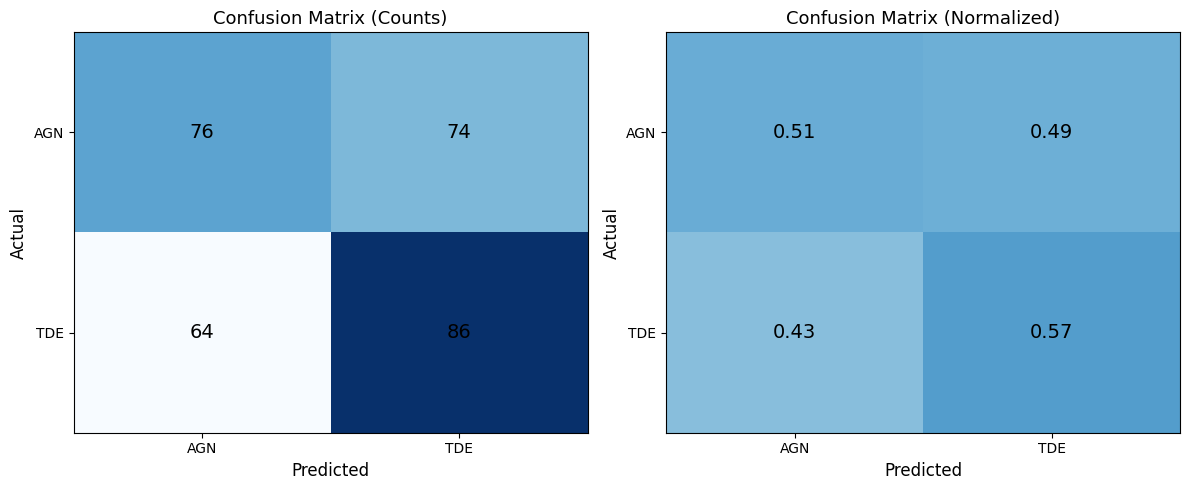

In [8]:
y_pred = clf.predict(X_test)
fig = create_confusion_matrix_plot(y_test, y_pred)
plt.show()

## Step 6: Visualize the embedding space

t-SNE projection of the 1792-dimensional embedding vectors. Well-separated clusters indicate that the ASTROMER representations carry discriminative information for this task.

Generating t-SNE...


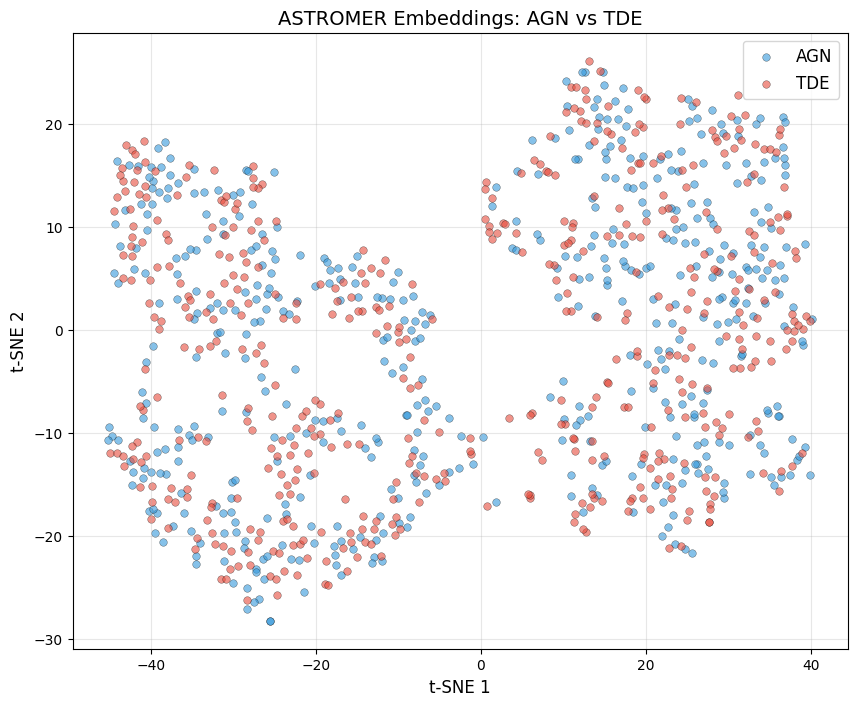

In [9]:
fig = pipeline.visualize_embeddings()
plt.show()

## Step 7: Feature importance

Which of the 1792 embedding dimensions matter most to the Random Forest? Each named group (e.g. `mean_feat`, `std_feat`) spans 256 consecutive dimensions.

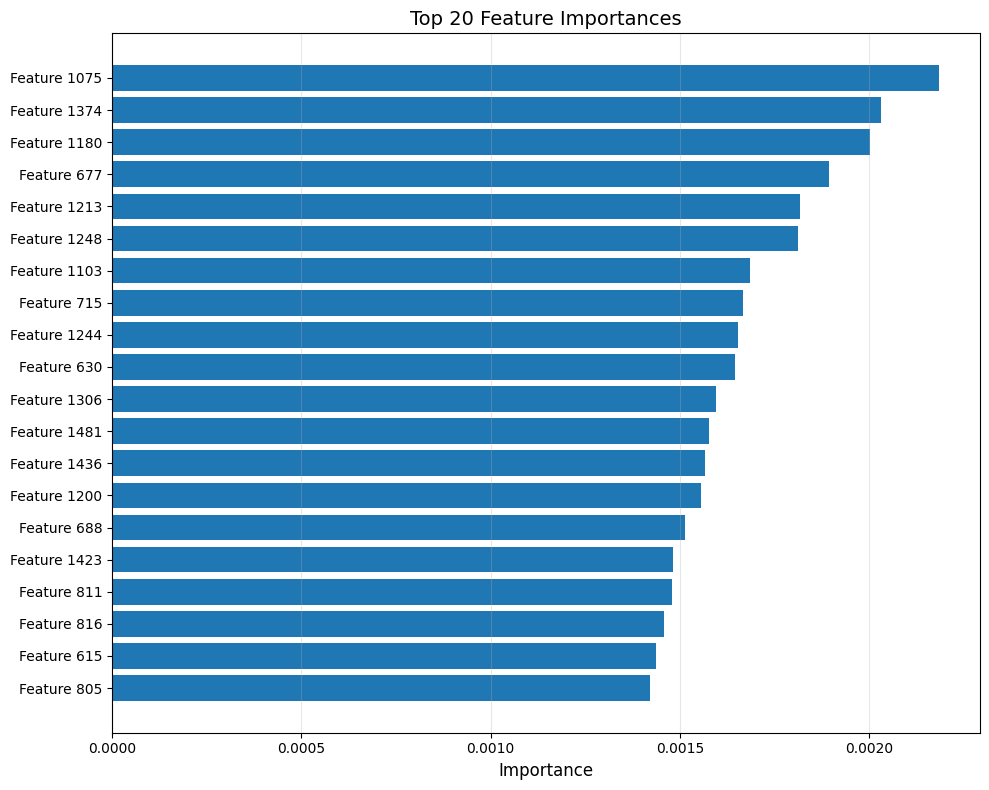

In [10]:
fig = analyze_feature_importance(clf, top_n=20)
plt.show()

## CLI equivalent

The entire notebook above runs as a single command:

```bash
fluctuant astromer \
    --n-agn 500 --n-tde 500 \
    --weights macho \
    --output-dir results/
```

Add `--tune` for Random Forest hyperparameter grid search, or `--augment` for data augmentation (noise jitter, time shift, magnitude offset).